<a href="https://colab.research.google.com/github/PutriBalqis134/FYP-HNSCC/blob/main/DNN_Mutation_ver_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import (Input, Dense, Embedding, Flatten, Concatenate, Dropout)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

#Dataset Input

In [94]:
# Load sample info for ID mapping
sample_info = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/sample_info_updated.csv')
print("Sample Info Shape:", sample_info.shape)
display(sample_info.head())

Sample Info Shape: (120, 2)


,depmapId,cellLineDisplayName
0,ACH-000740,A253
1,ACH-002212,BB30HNC
2,ACH-002213,BB49HNC
3,ACH-000548,BHY
4,ACH-001331,BICR10


In [95]:
# Load mutation data
mutation_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/Mutation_HNSCC_filtered.csv')

mutation_df = mutation_df[["depmapId", "Hugo_Symbol", "Variant_Classification", "Variant_Type"]]

print("Mutation :", mutation_df.shape)
display(mutation_df.head())

Mutation : (72004, 4)


,depmapId,Hugo_Symbol,Variant_Classification,Variant_Type
0,ACH-000163,AL627309.1,Silent,SNP
1,ACH-000163,CLCN6,Silent,SNP
2,ACH-000163,KAZN,Missense_Mutation,SNP
3,ACH-000163,PLEKHM2,Silent,SNP
4,ACH-000163,HTR6,Silent,SNP


In [96]:
#convert mutation to binary
mutation_df["Mutation"] = 1

#convert mutation dataset into matrix
mutation_matrix = mutation_df.pivot_table(
    index="depmapId",
    columns="Hugo_Symbol",
    values="Mutation",
    aggfunc="max").fillna(0)

print("Matrix shape before data filter :", mutation_matrix.shape)

#keep only genes that contain mutation in atleast 3 cell lines
gene_freq = mutation_matrix.sum(axis=0)
mutation_matrix = mutation_matrix.loc[:, gene_freq >= 3]

print("Matrix shape after data filter :", mutation_matrix.shape)
display(mutation_matrix.head())

Matrix shape before data filter : (86, 14169)
Matrix shape after data filter : (86, 5635)


Hugo_Symbol,36951,37681,37865,38412,38777,39142,39326,40238,40603,41883,...,ZSCAN29,ZSCAN5A,ZSCAN5B,ZSWIM5,ZSWIM6,ZSWIM8,ZXDC,ZYG11A,ZZEF1,ZZZ3
depmapId,,,,,,,,,,,,,,,,,,,,,
ACH-000163,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
ACH-000181,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACH-000188,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACH-000207,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACH-000228,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [97]:
# Load drug response dataset (logIC50)
ic50_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/HNSCC_IC50.csv')

print("GDSC IC50 Shape:", ic50_df.shape)
display(ic50_df.head())

GDSC IC50 Shape: (9408, 12)


,Drug Name,Drug ID,cellLineDisplayName,Cosmic ID,TCGA Classification,Tissue,Tissue Sub-type,IC50,AUC,Max Conc,RMSE,Z score
0,Camptothecin,1003,BB30HNC,753531,HNSC,aero_digestive_tract,head_and_neck,-4.016599,0.729320,0.1,0.121919,-0.956747
1,Camptothecin,1003,BB49HNC,753532,HNSC,aero_digestive_tract,head_and_neck,-2.024280,0.867884,0.1,0.109995,0.128007
2,Camptothecin,1003,BHY,753535,HNSC,aero_digestive_tract,head_and_neck,-2.081150,0.872193,0.1,0.068698,0.097043
3,Camptothecin,1003,Ca922,753538,HNSC,aero_digestive_tract,head_and_neck,-3.523805,0.764404,0.1,0.095041,-0.688436
4,Camptothecin,1003,CAL33,753541,HNSC,aero_digestive_tract,head_and_neck,-3.711201,0.746475,0.1,0.094559,-0.790468


#Data Preprocess

In [98]:
#build mapping table to align key ids from all datasets
map_df = sample_info[["depmapId", "cellLineDisplayName"]].drop_duplicates()

#merge ic50 dataset with sample_info to align depmapId
ic50 = ic50_df.merge(map_df, on="cellLineDisplayName", how="inner")

ic50 = ic50[["depmapId", "Drug Name", "IC50"]]

print(ic50_df.shape)
print(ic50.shape)
ic50.head()

(9408, 12)
(9127, 3)


,depmapId,Drug Name,IC50
0,ACH-002212,Camptothecin,-4.016599
1,ACH-002213,Camptothecin,-2.024280
2,ACH-000548,Camptothecin,-2.081150
3,ACH-002043,Camptothecin,-3.523805
4,ACH-000518,Camptothecin,-3.711201


In [99]:
#merge mutation dataset with mapped IC50 dataset
merged_df = pd.merge(
    ic50,
    mutation_matrix,
    on='depmapId',
    how='inner')

print("Merged mutation + IC50 Shape:", merged_df.shape)
display(merged_df.head())

Merged mutation + IC50 Shape: (5437, 5638)


,depmapId,Drug Name,IC50,36951,37681,37865,38412,38777,39142,39326,...,ZSCAN29,ZSCAN5A,ZSCAN5B,ZSWIM5,ZSWIM6,ZSWIM8,ZXDC,ZYG11A,ZZEF1,ZZZ3
0,ACH-000548,Camptothecin,-2.081150,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,ACH-000518,Camptothecin,-3.711201,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ACH-000472,Camptothecin,-4.336130,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ACH-001543,Camptothecin,-3.099968,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ACH-000207,Camptothecin,-2.823572,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [100]:
# Select only numerical and boolean columns for X
feature_columns = merged_df.select_dtypes(include=[np.number, bool]).columns.tolist()

# Ensure 'IC50' and 'depmapId' is not in feature_columns if it somehow got included
if 'IC50' in feature_columns:
    feature_columns.remove('IC50')

if 'depmapId' in feature_columns:
    feature_columns.remove('depmapId')

X = merged_df[feature_columns].values
y = merged_df['IC50'].values

print(f"Final X shape: {X.shape}")
print(f"Final y shape: {y.shape}")

Final X shape: (5437, 5635)
Final y shape: (5437,)


In [101]:
#transform 'Drug Name' into 'Drug_ID' because string cannot be used directly as input
drug_encoder = LabelEncoder()

merged_df["Drug_ID"] = drug_encoder.fit_transform(
    merged_df["Drug Name"])

num_drugs = merged_df["Drug_ID"].nunique()
print("Number of drugs:", num_drugs)

Number of drugs: 288


In [102]:
#prepare X (features) and y (target)
feature_columns = mutation_matrix.columns.tolist()

X_mut = merged_df[feature_columns].values

X_drug = merged_df["Drug_ID"].values

y = merged_df["IC50"].values

print(X_mut.shape)
print(X_drug.shape)
print(y.shape)

(5437, 5635)
(5437,)
(5437,)


#Train-Test Split and Data Normalization


In [156]:
# Split data into training and testing sets
indices = np.arange(len(X_mut))
(   X_mut_train,
    X_mut_test,
    X_drug_train,
    X_drug_test,
    y_train,
    y_test,
    train_idx,
    test_idx ) = train_test_split (X_mut,
                                   X_drug,
                                   y,
                                   indices,
                                   test_size=0.2,
                                   random_state=42)

print("X_mut_train:", X_mut_train.shape)
print("X_mut_test :", X_mut_test.shape)

print("X_drug_train:", X_drug_train.shape)
print("X_drug_test :", X_drug_test.shape)

print("y_train:", y_train.shape)

X_mut_train: (4349, 5635)
X_mut_test : (1088, 5635)
X_drug_train: (4349,)
X_drug_test : (1088,)
y_train: (4349,)


# Build and Compile the DNN Model

In [157]:
#Mutation branch
mut_input = Input(shape=(X_mut_train.shape[1],), name="Mutation_Input")

mut_branch = Dense(
    128,
    activation="relu",
    kernel_regularizer=l2(0.001))(mut_input)

mut_branch = Dropout(0.2)(mut_branch)

In [158]:
#Drug embedding branch
drug_input = Input(
    shape=(1,),
    name="Drug_Input")

drug_embedding = Embedding(
    input_dim=num_drugs,
    output_dim=32)(drug_input)

drug_embedding = Flatten()(drug_embedding)

In [159]:
merged = Concatenate()(
    [mut_branch, drug_embedding])

In [160]:
#Dense layer
merged = Dense(
    64,
    activation="relu",
    kernel_regularizer=l2(0.001))(merged)

merged = Dropout(0.3)(merged)

In [161]:
#output
output = Dense(1, activation="linear")(merged)

In [162]:
model = Model(
    inputs=[mut_input, drug_input],
    outputs=output)

model.compile(
    optimizer=Adam(0.00005),
    loss="mse",
    metrics=["mse"])

model.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Mutation_Input      │ (None, 5635)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Drug_Input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_39 (Dense)    │ (None, 128)       │    721,408 │ Mutation_Input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_13        │ (None, 1, 32)     │      9,216 │ Drug_Input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_26          │ (None, 128)       │          0 │ dense_39[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_13          │ (None, 32)        │          0 │ embedding_13[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_13      │ (None, 160)       │          0 │ dropout_26[0][0], │
│ (Concatenate)       │                   │            │ flatten_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_40 (Dense)    │ (None, 64)        │     10,304 │ concatenate_13[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_27          │ (None, 64)        │          0 │ dense_40[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_41 (Dense)    │ (None, 1)         │         65 │ dropout_27[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 740,993 (2.83 MB)

 Trainable params: 740,993 (2.83 MB)

 Non-trainable params: 0 (0.00 B)

#Train the Model

In [163]:
history = model.fit(
    [X_mut_train, X_drug_train],
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1)

print("\nModel training complete with best weights restored.")

Epoch 1/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 10.5838 - mse: 10.2742 - val_loss: 6.8152 - val_mse: 6.5311
Epoch 2/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 7.6324 - mse: 7.3658 - val_loss: 6.3466 - val_mse: 6.0951
Epoch 3/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 7.3122 - mse: 7.0712 - val_loss: 6.3097 - val_mse: 6.0778
Epoch 4/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 7.3105 - mse: 7.0848 - val_loss: 6.3151 - val_mse: 6.0949
Epoch 5/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 7.2479 - mse: 7.0313 - val_loss: 6.3814 - val_mse: 6.1680
Epoch 6/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 7.1566 - mse: 6.9452 - val_loss: 6.2909 - val_mse: 6.0814
Epoch 7/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.1361 - mse: 6.9278 - val_loss: 6.2003 - val_mse: 5.9930
Epoch 8/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.0917 - mse: 6.8852 - val_loss: 6.2074 - val_mse: 6.0016
Epoch 9/100
109/109 ━━━━━━━━━━━━━━━━━━

#Evaluate the Model

In [164]:
# Make predictions on the test set
y_pred = model.predict([X_mut_test, X_drug_test])

# Evaluate the model on test data
mse = mean_squared_error(y_test, y_pred)
print("\nTest Loss (MSE): ", mse)

# Calculate R-squared
r2 = r2_score(y_test, y_pred)
print("Test R-squared (R²): ", r2)

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Test Loss (MSE):  1.2068994188634836
Test R-squared (R²):  0.8360667739469901


In [165]:
# Get original test rows
test_df_original = merged_df.iloc[test_idx].copy()

# Add actual and predicted values
test_df_original["actual_IC50"] = y_test
test_df_original["predicted_IC50"] = y_pred.flatten()

drug_r2_scores = []

MIN_SAMPLES = 3

for drug_name, drug_subset in test_df_original.groupby("Drug Name"):

    if len(drug_subset) >= MIN_SAMPLES:

        r2 = r2_score(
            drug_subset["actual_IC50"],
            drug_subset["predicted_IC50"])

        drug_r2_scores.append({
            "Drug Name": drug_name,
            "R²": r2,
            "n_test_samples": len(drug_subset)
            })

if len(drug_r2_scores) > 0:

    drug_r2_df = pd.DataFrame(drug_r2_scores)

    drug_r2_df = drug_r2_df.sort_values(
        by="R²",
        ascending=False)

    print("Top 3 drugs by R²:")
    display(drug_r2_df.head(3))

else:
    print("No drugs have at least", MIN_SAMPLES, "test samples.")

Top 3 drugs by R²:


,Drug Name,R²,n_test_samples
42,CT7033-2,0.831304,3
7,776928,0.828009,4
8,AGI-5198,0.804953,5


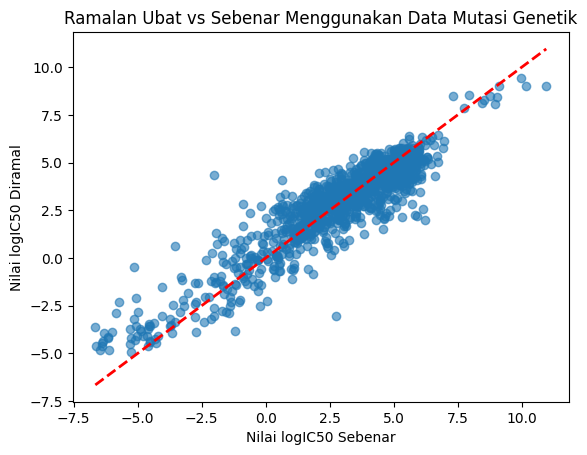

In [167]:
import matplotlib.pyplot as plt

# Contoh untuk model Mutasi Gen
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)  # garis y=x untuk rujukan
plt.xlabel('Nilai logIC50 Sebenar')
plt.ylabel('Nilai logIC50 Diramal')
plt.title('Ramalan Ubat vs Sebenar Menggunakan Data Mutasi Genetik')
plt.show()
